# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42999 sha256=a1a7cec4dbd78353f9ab152dc83c3eb5a5a09aebe0936f01da0a9f9ea3ec189a
  Stored in directory: c:\users\aseem\appdata\local\pip\cache\wheels\e9\7b\12\c4dd11e23f8cdb4e8fecf1b087e272836977afbb44936b80be
Successfully built assertpy
Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [8]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    padded = (start_symbol * (n - 1)) + text + (end_symbol * n)
    for i in range(len(padded) - n + 1):
        yield padded[i:i + n]

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [10]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 28149.69it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 139810.13it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [12]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram + 1, n_ngram + 1), dtype=np.float64)
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            # Get N-gram index, or unknown index if unseen
            idx = n2i_mapping.get(ngram, unknown_idx)
            
            # Update co-occurrence with previous neighbors in the window
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] = co_matrix.get((idx, prev_idx), 0) + 1
                co_matrix[prev_idx, idx] = co_matrix.get((prev_idx, idx), 0) + 1
            
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = np.asarray(co_matrix.sum(axis=1)).flatten()
    
    # Normalize each row so it sums to 1
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i] > 0:
            co_matrix[i, j] = co_matrix[i, j] / row_sums[i]
    
    return co_matrix

In [14]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 31980.97it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2178430.95it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [14:27<00:00, 41.86it/s]


Normalizing...


100%|██████████| 2542234/2542234 [02:59<00:00, 14126.14it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [15]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [17]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        # Pad or truncate URL to fixed length
        url = url[:padded_len].ljust(padded_len, pad_symbol)
        
        # Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [18]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [19]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        # Embedding layer (frozen)
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_weights, dtype=torch.float32),
            freeze=True
        )
        
        # Conv blocks
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        
        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)
        
        # FC layers
        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)          # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)         # (batch, embed_dim, seq_len)
        
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x)).squeeze(1)
        
        return x

In [20]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [21]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
        
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [22]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.7372, Val Acc=0.8809
Epoch 2: Train Acc=0.8910, Val Acc=0.9064
Epoch 3: Train Acc=0.9073, Val Acc=0.9131
Epoch 4: Train Acc=0.9126, Val Acc=0.9077
Epoch 5: Train Acc=0.9153, Val Acc=0.9199
Epoch 6: Train Acc=0.9214, Val Acc=0.9262
Epoch 7: Train Acc=0.9271, Val Acc=0.9368
Epoch 8: Train Acc=0.9312, Val Acc=0.9355
Epoch 9: Train Acc=0.9321, Val Acc=0.9329
Epoch 10: Train Acc=0.9356, Val Acc=0.9365


## 6. Evaluation

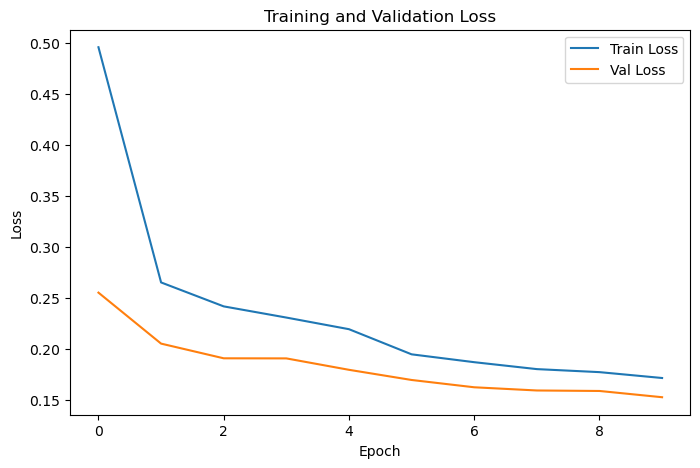

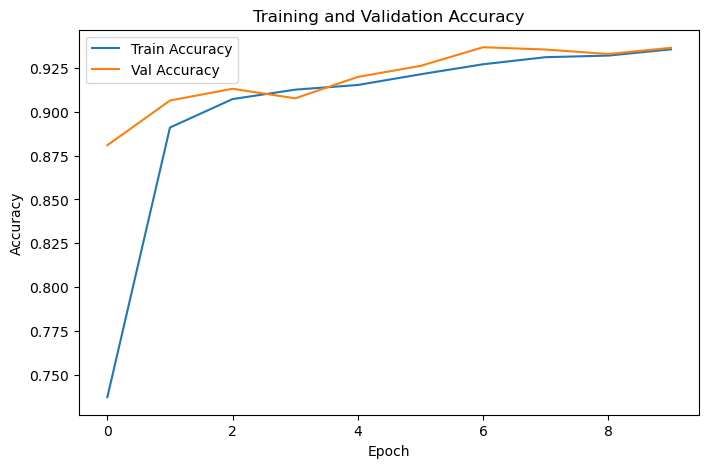

In [23]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history['acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

# Create test dataset and loader
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Predict and collect results
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = (out > 0.5).long().cpu().numpy()
        
        y_pred.extend(preds)
        y_true.extend(y.numpy().astype(int))

# Print confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
[[6576  567]
 [ 243 4724]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9644    0.9206    0.9420      7143
           1     0.8928    0.9511    0.9210      4967

    accuracy                         0.9331     12110
   macro avg     0.9286    0.9358    0.9315     12110
weighted avg     0.9350    0.9331    0.9334     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:**

The model performs well overall, with 93.31% test accuracy and strong F1-scores for both classes. It detects malicious URLs effectively: for class 1, recall is 0.9511, which means it catches most malicious samples. Precision for class 1 is 0.8928, so some benign URLs are still being flagged as malicious. From the confusion matrix, there are 243 false negatives and 567 false positives, so the model is slightly more aggressive about predicting malicious URLs, which is often preferable in a security setting.

Lower loss usually tends to correlate with higher accuracy, but it does not always guarantee it. Loss measures how confident the model’s predicted probabilities are, while accuracy only checks whether the final predicted class is correct. A model can have lower loss without a large accuracy improvement if it becomes more confident on predictions that were already correct, or accuracy can stay similar even when loss changes.


**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**

A very large window_size like 50 is usually not ideal for URL N-gram co-occurrence. URLs are short, structured strings, so nearby N-grams tend to carry the most meaningful local patterns. A huge window can mix together weakly related parts of the URL, add noise to the co-occurrence matrix, and increase computation and memory cost. It may blur important local malicious patterns instead of sharpening them.

Other compression methods besides TruncatedSVD include PCA, autoencoders, and learned embedding layers trained directly with the CNN. PCA is common for dense data, but SVD is usually better for sparse co-occurrence matrices. Autoencoders can learn nonlinear compressed representations, while end-to-end trainable embeddings often work well because they adapt specifically to the classification task rather than only preserving co-occurrence structure.

## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`